# Synthetic Data Experiment - BESSTIE vs Synthetic Data

This notebook follows the same section order and overall structure as `Q1_analyse_visualise_dataset.ipynb`, but adapts the analysis to compare a synthetic dataset against the BESSTIE corpus. The aim is to examine how closely the synthetic texts resemble BESSTIE in terms of labels, domain effects, lexical overlap, and linguistic patterns.

## Section 1 - Install Dependencies

This section installs the required packages used for loading the dataset, plotting figures, and running linguistic analyses.

In [1]:
import sys
%pip -q install datasets matplotlib matplotlib-venn nltk numpy pandas seaborn scikit-learn spacy transformers
!{sys.executable} -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Section 2 - Import Requirements and Create Output Folder

This section imports all required libraries and creates the output directories used to save plots and summary tables.

In [2]:
import os, re
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy

from collections import Counter
from datasets import load_dataset
from matplotlib_venn import venn3
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")
sns.set_context("talk")

# Paths
ROOT_DIR    = os.getcwd()
OUT_DIR     = f"{ROOT_DIR}/Results"
PLOTS_DIR   = os.path.join(OUT_DIR, "plots")
CSV_DIR   = os.path.join(OUT_DIR, "csv")
SYNTHETIC_CSV_PATH = f"{ROOT_DIR}/synthetic_besstie_like.csv"

for d in [OUT_DIR, PLOTS_DIR, CSV_DIR]:
    os.makedirs(d, exist_ok=True)

[nltk_data] Downloading package punkt to
[nltk_data]     /user/HS401/zt00372/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /user/HS401/zt00372/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Section 3 - Load dataset from Hugging Face

This section loads the BESSTIE dataset from Hugging Face and reads the synthetic CSV file that will be compared against the original corpus.

In [3]:
dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")
synthetic_data_frames = pd.read_csv(SYNTHETIC_CSV_PATH)

print(dataset)
print("\nSynthetic shape:", synthetic_data_frames.shape)
print("Synthetic columns:", synthetic_data_frames.columns.tolist())

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

Synthetic shape: (1244, 5)
Synthetic columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


## Section 4 - Convert Splits to Data Frames

This section converts the BESSTIE splits into pandas DataFrames and creates the combined BESSTIE dataframe used for overview analyses.

In [4]:
train = dataset['train'].to_pandas()
validation = dataset['validation'].to_pandas()
test = dataset['test'].to_pandas()

# Add split labels
train['split'] = 'Train'
validation['split'] = 'Validation'
test['split'] = 'Test'

# Combined dataframe for overview analysis
data_frames = pd.concat([train, validation, test], ignore_index=True)

# Standardize synthetic columns
synthetic_data_frames['text'] = synthetic_data_frames['text'].astype(str)
synthetic_data_frames['variety'] = synthetic_data_frames['variety'].astype(str)
synthetic_data_frames['source'] = synthetic_data_frames['source'].astype(str)
synthetic_data_frames['Sentiment'] = synthetic_data_frames['Sentiment'].astype(int)
synthetic_data_frames['Sarcasm'] = synthetic_data_frames['Sarcasm'].astype(int)

print("Full BESSTIE dataset shape:", data_frames.shape)
print("\nVariety counts:\n", data_frames['variety'].value_counts())
print("\nSource counts:\n", data_frames['source'].value_counts())

Full BESSTIE dataset shape: (6243, 6)

Variety counts:
 variety
en-IN    2332
en-UK    2004
en-AU    1907
Name: count, dtype: int64

Source counts:
 source
Google    3142
Reddit    3101
Name: count, dtype: int64


## Section 5 - Explore Structure

This section inspects the structure of both datasets to verify available fields and sample entries before running the comparison analyses.

In [5]:
for split_name in dataset.keys():
    print(f"[{split_name.title()}]")
    print(f"Rows: {len(dataset[split_name])}")
    print(f"Columns: {dataset[split_name].column_names}")
    print(f"{dataset[split_name].to_pandas().head(3)}\n")

print("[Synthetic]")
print(f"Rows: {len(synthetic_data_frames)}")
print(f"Columns: {synthetic_data_frames.columns.tolist()}")
print(synthetic_data_frames.head(5))

[Train]
Rows: 3747
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  

[Validation]
Rows: 313
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
                                                text variety  source  \
0  Had a great meal here. Friendly service, great...   en-AU  Google   
1  Meh. Such a shame. Such a waste. Only single u...   en-AU  Google   
2  How many sensors are broken? It is 28 degrees ...   en-IN  Reddit   

   Sentiment  Sarcasm  
0        1.0      0.0  
1        0.0      0.0  
2        0.0      1.0  

[Test]
Rows: 2183
Columns: ['text', 'variety', 'source', 'Se

## Section 6 - Dataset Summary Table

This section provides a compact numerical overview of BESSTIE and the synthetic dataset, including counts by split, variety, source, and label.

In [6]:
summary_rows = []

for split_name, data_frame in [('Train', train), ('Validation', validation), ('Test', test)]:
    summary_rows.append({
        'Dataset': 'BESSTIE',
        'split': split_name,
        'rows': len(data_frame),
        'en-AU': int((data_frame['variety'] == 'en-AU').sum()),
        'en-IN': int((data_frame['variety'] == 'en-IN').sum()),
        'en-UK': int((data_frame['variety'] == 'en-UK').sum()),
        'Google': int((data_frame['source'] == 'Google').sum()),
        'Reddit': int((data_frame['source'] == 'Reddit').sum()),
        'Positive': int((data_frame['Sentiment'] == 1).sum()),
        'Negative': int((data_frame['Sentiment'] == 0).sum()),
        'Sarcastic': int((data_frame['Sarcasm'] == 1).sum()),
        'Not Sarcastic': int((data_frame['Sarcasm'] == 0).sum()),
    })

summary_rows.append({
    'Dataset': 'Synthetic',
    'split': 'Synthetic',
    'rows': len(synthetic_data_frames),
    'en-AU': int((synthetic_data_frames['variety'] == 'en-AU').sum()),
    'en-IN': int((synthetic_data_frames['variety'] == 'en-IN').sum()),
    'en-UK': int((synthetic_data_frames['variety'] == 'en-UK').sum()),
    'Google': int((synthetic_data_frames['source'] == 'Google').sum()),
    'Reddit': int((synthetic_data_frames['source'] == 'Reddit').sum()),
    'Positive': int((synthetic_data_frames['Sentiment'] == 1).sum()),
    'Negative': int((synthetic_data_frames['Sentiment'] == 0).sum()),
    'Sarcastic': int((synthetic_data_frames['Sarcasm'] == 1).sum()),
    'Not Sarcastic': int((synthetic_data_frames['Sarcasm'] == 0).sum()),
})

summary_data_frames = pd.DataFrame(summary_rows)
display(summary_data_frames)
summary_data_frames.to_csv(f'{CSV_DIR}/synthetic_dataset_summary.csv', index=False)

,Dataset,split,rows,en-AU,en-IN,en-UK,Google,Reddit,Positive,Negative,Sarcastic,Not Sarcastic
0,BESSTIE,Train,3747,1145,1399,1203,1874,1873,1840,1907,524,3223
1,BESSTIE,Validation,313,95,117,101,167,146,153,160,44,269
2,BESSTIE,Test,2183,667,816,700,1101,1082,1066,1117,305,1878
3,Synthetic,Synthetic,1244,408,311,418,625,619,395,849,630,614


## Section 7 - Text Length Distribution

This section compares text length between BESSTIE and the synthetic dataset. To reduce scale imbalance, it uses a size-matched BESSTIE sample for the visual comparison.

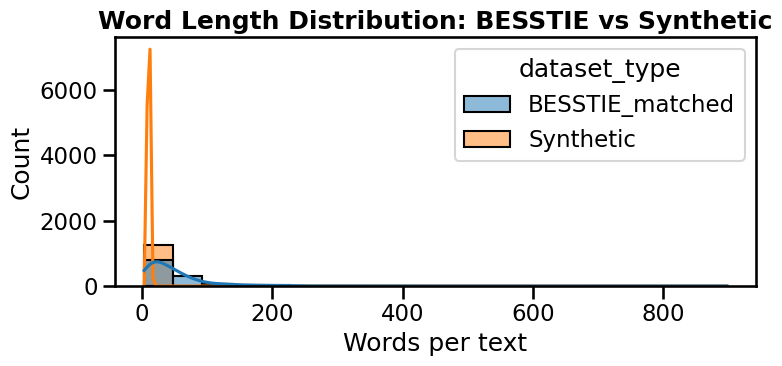

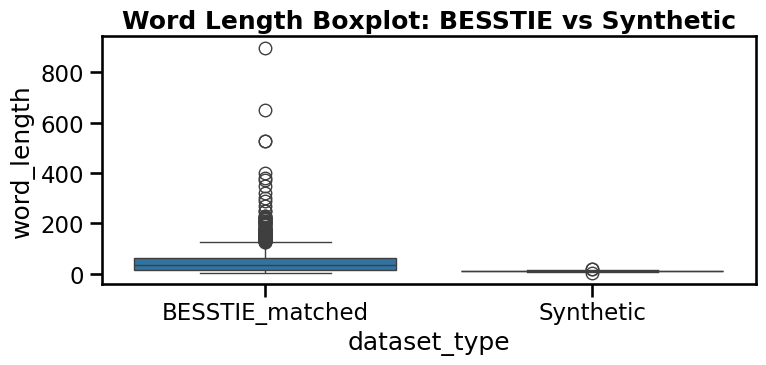

                  mean  median    std  min  max
dataset_type                                   
BESSTIE_matched  49.19    34.0  58.98    3  898
Synthetic        10.33    10.0   2.39    4   17


In [7]:
# Match BESSTIE size to synthetic for fair comparison
matched_frames = data_frames.sample(n=len(synthetic_data_frames), random_state=42).copy()
matched_frames['dataset_type'] = 'BESSTIE_matched'
synthetic_data_frames['dataset_type'] = 'Synthetic'

for data_frame in [matched_frames, synthetic_data_frames]:
    data_frame['word_length'] = data_frame['text'].astype(str).apply(lambda x: len(x.split()))

comparison_frames = pd.concat([matched_frames, synthetic_data_frames], ignore_index=True)

plt.figure(figsize=(8, 4))
sns.histplot(data=comparison_frames, x='word_length', hue='dataset_type', bins=20, kde=True)
plt.title('Word Length Distribution: BESSTIE vs Synthetic', fontweight='bold')
plt.xlabel('Words per text')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_word_length_hist.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=comparison_frames, x='dataset_type', y='word_length')
plt.title('Word Length Boxplot: BESSTIE vs Synthetic', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_word_length_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(comparison_frames.groupby('dataset_type')['word_length'].agg(['mean', 'median', 'std', 'min', 'max']).round(2))

## Section 8 - Split-Wise Label Distribution

This section keeps the original BESSTIE split-wise distribution analysis in order to contextualize the synthetic comparison against the real data structure.

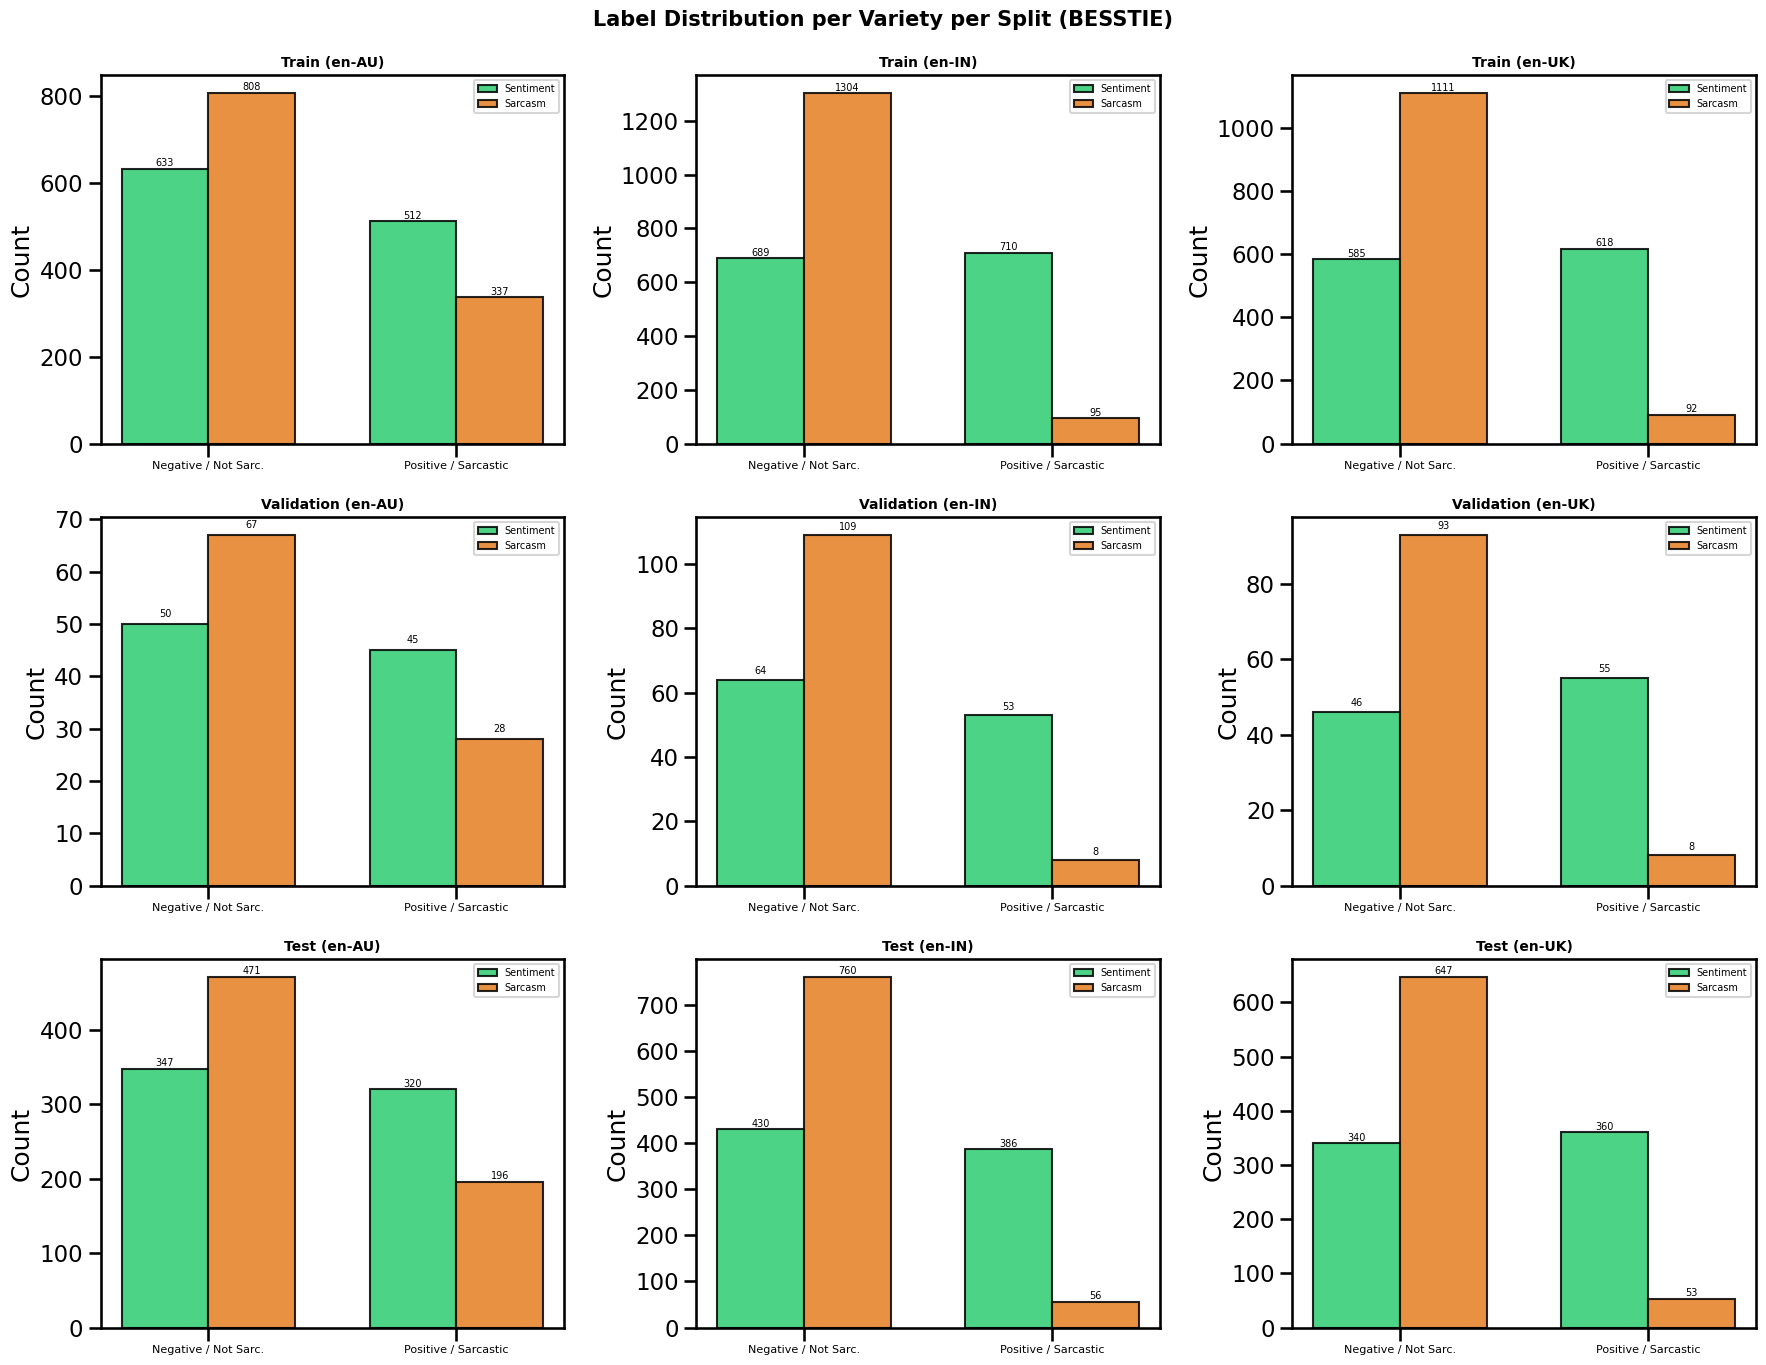

In [8]:
varieties = ['en-AU', 'en-IN', 'en-UK']
splits = ['Train', 'Validation', 'Test']
tasks = ['Sentiment', 'Sarcasm']

figure, axes = plt.subplots(3, 3, figsize=(18, 14))
figure.suptitle('Label Distribution per Variety per Split (BESSTIE)', fontsize=15, fontweight='bold')

for row, split in enumerate(splits):
    for col, variety in enumerate(varieties):
        ax = axes[row][col]
        subset = data_frames[
            (data_frames['variety'] == variety) &
            (data_frames['split'] == split)
        ]

        sarcasm_counts = subset['Sarcasm'].value_counts().sort_index()
        sentiment_counts = subset['Sentiment'].value_counts().sort_index()

        x = np.arange(2)
        width = 0.35

        sarc_vals = [sarcasm_counts.get(0.0, 0), sarcasm_counts.get(1.0, 0)]
        sent_vals = [sentiment_counts.get(0.0, 0), sentiment_counts.get(1.0, 0)]

        ax.bar(x - width/2, sent_vals, width, label='Sentiment',
               color='#2ecc71', alpha=0.85, edgecolor='black')
        ax.bar(x + width/2, sarc_vals, width, label='Sarcasm',
               color='#e67e22', alpha=0.85, edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(['Negative / Not Sarc.', 'Positive / Sarcastic'], fontsize=8)
        ax.set_title(f'{split} ({variety})', fontsize=10, fontweight='bold')
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)
        
        # Add count labels
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(int(bar.get_height())), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_split_distribution_reference.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 - Sentiment and Sarcasm Distribution Across Varieties

This section compares how label proportions vary across varieties in the matched BESSTIE sample and the synthetic dataset.

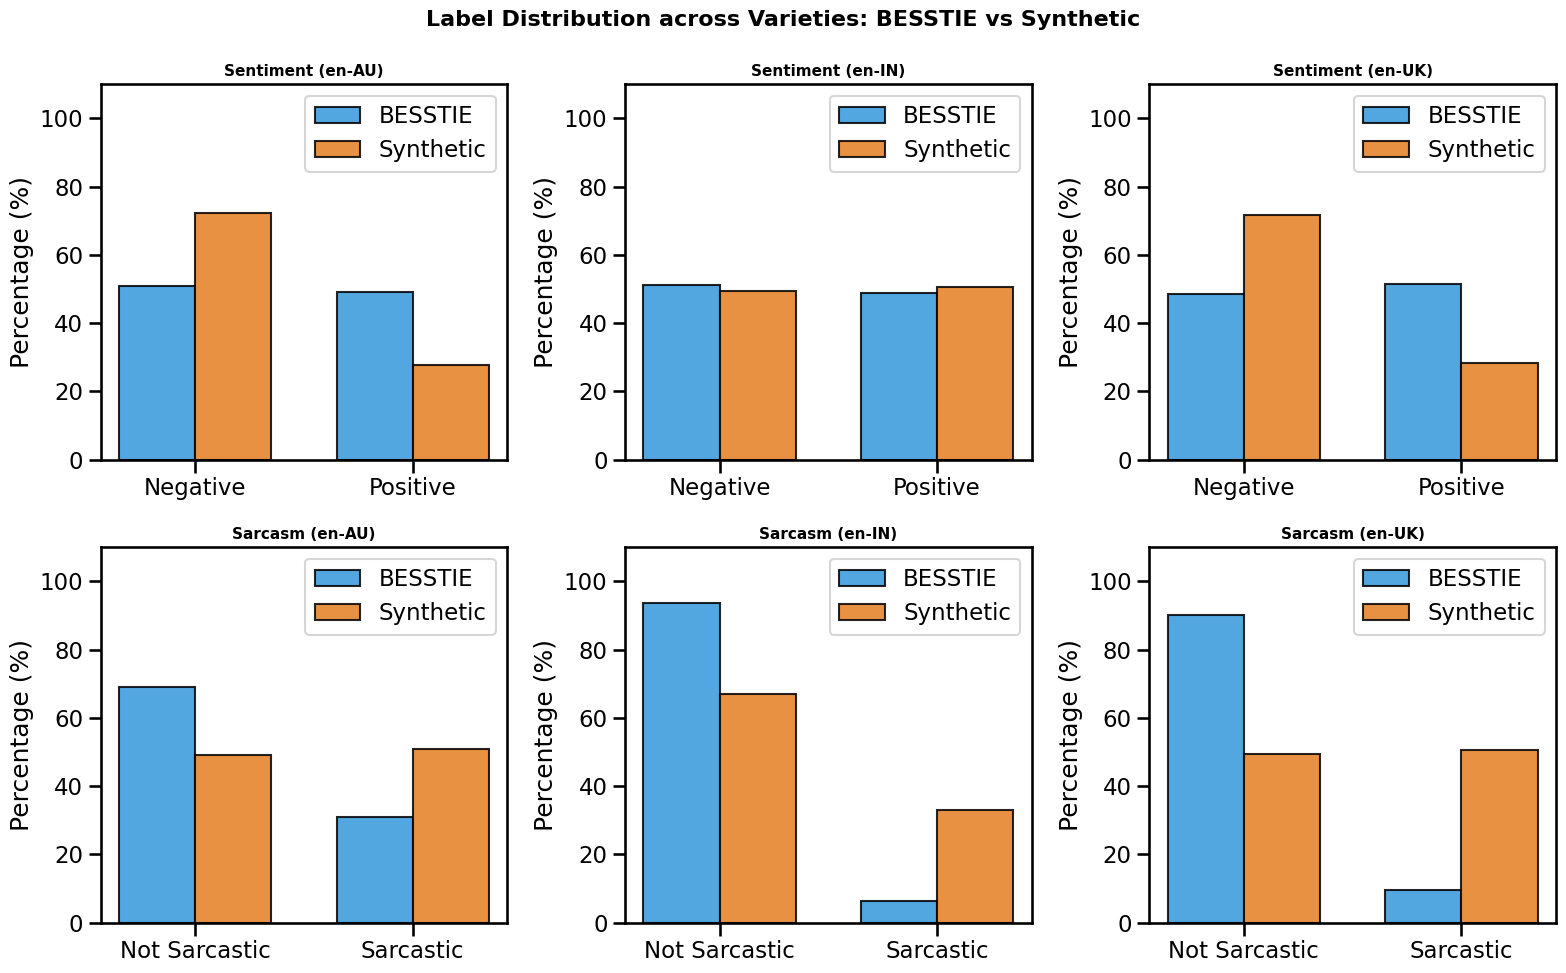

In [9]:
figure, axes = plt.subplots(2, 3, figsize=(16, 10))
figure.suptitle('Label Distribution across Varieties: BESSTIE vs Synthetic', fontsize=16, fontweight='bold')

label_names = {
    'Sentiment': {0: 'Negative', 1: 'Positive'},
    'Sarcasm': {0: 'Not Sarcastic', 1: 'Sarcastic'}
}
colors = {'BESSTIE_matched': '#3498db', 'Synthetic': '#e67e22'}

for row, task in enumerate(tasks):
    for col, variety in enumerate(varieties):
        ax = axes[row][col]
        subset_real = matched_frames[matched_frames['variety'] == variety]
        subset_syn  = synthetic_data_frames[synthetic_data_frames['variety'] == variety]

        real = subset_real[task].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100
        syn  = subset_syn[task].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100

        x = np.arange(2)
        width = 0.35
        labels = [label_names[task][0], label_names[task][1]]

        ax.bar(x - width/2, real.values, width, label='BESSTIE', color=colors['BESSTIE_matched'], alpha=0.85, edgecolor='black')
        ax.bar(x + width/2, syn.values, width, label='Synthetic', color=colors['Synthetic'], alpha=0.85, edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_title(f'{task} ({variety})', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percentage (%)')
        ax.set_ylim(0, 110)
        ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_label_distribution_varieties.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10 - Domain Analysis (Google vs Reddit)

This section compares label proportions by source domain between matched BESSTIE data and the synthetic dataset.

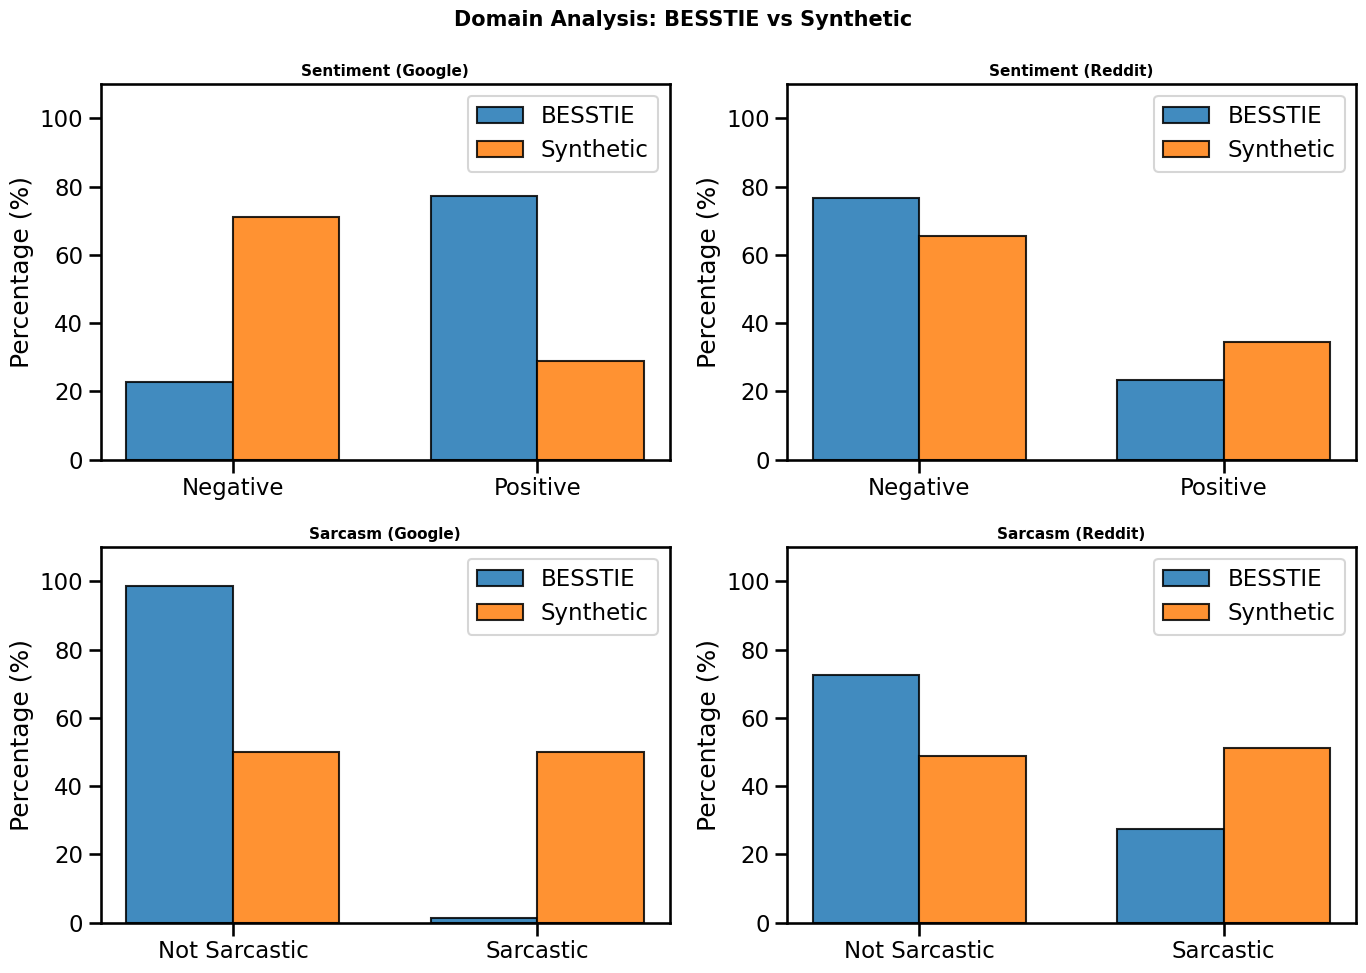

In [10]:
figure, axes = plt.subplots(2, 2, figsize=(14, 10))
figure.suptitle('Domain Analysis: BESSTIE vs Synthetic', fontsize=15, fontweight='bold')

for row, task in enumerate(tasks):
    for col, domain in enumerate(['Google', 'Reddit']):
        ax = axes[row][col]

        real = matched_frames[matched_frames['source'] == domain][task].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100
        syn  = synthetic_data_frames[synthetic_data_frames['source'] == domain][task].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100

        x = np.arange(2)
        width = 0.35
        labels = [label_names[task][0], label_names[task][1]]

        ax.bar(x - width/2, real.values, width, label='BESSTIE', color='#1f77b4', alpha=0.85, edgecolor='black')
        ax.bar(x + width/2, syn.values, width, label='Synthetic', color='#ff7f0e', alpha=0.85, edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_title(f'{task} ({domain})', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percentage (%)')
        ax.set_ylim(0, 110)
        ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_domain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 - Sarcasm Imbalance by Domain and Variety

This section compares sarcasm rates across variety–domain combinations in BESSTIE and the synthetic dataset.

[BESSTIE Matched]
Variety Source  Sarcasm %  Positive Sentiment %  Count
  en-AU Google        4.7                  79.1    129
  en-AU Reddit       45.4                  32.8    238
  en-IN Google        0.8                  75.7    243
  en-IN Reddit       11.9                  22.9    253
  en-UK Google        0.0                  78.0    236
  en-UK Reddit       25.5                   8.3    145

[Synthetic]
Variety Source  Sarcasm %  Positive Sentiment %  Count
  en-AU Google       51.2                  28.8    205
  en-AU Reddit       50.7                  26.6    203
  en-IN Google       49.8                  25.6    207
  en-IN Reddit        0.0                 100.0    104
  en-UK Google       49.3                  32.4    213
  en-UK Reddit       52.2                  23.9    205


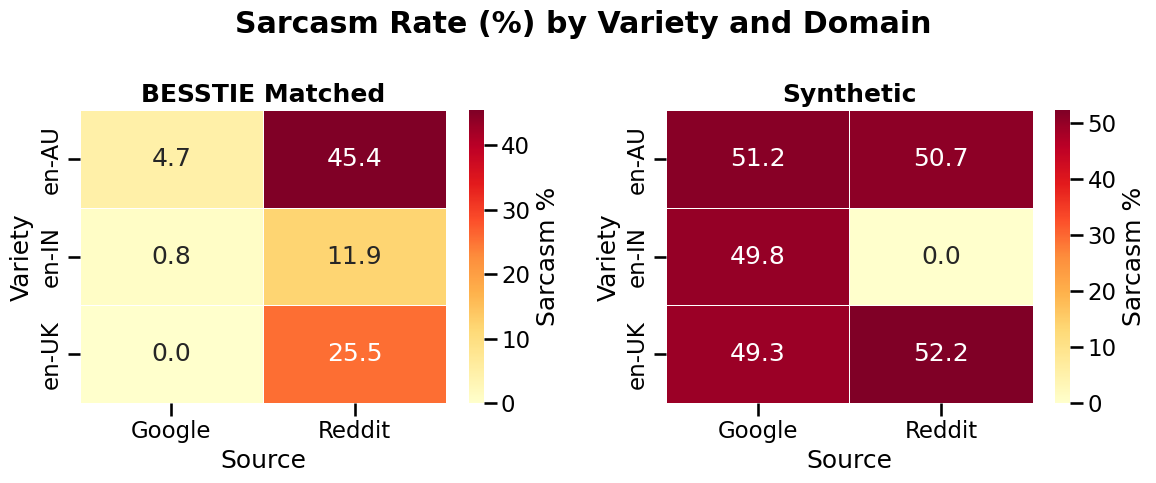

In [11]:
def build_sarcasm_summary(df):
    rows = []
    for variety in varieties:
        for source in ['Google', 'Reddit']:
            subset = df[(df['variety'] == variety) & (df['source'] == source)]
            if len(subset) == 0:
                continue
            sarcasm_percentage = subset['Sarcasm'].mean() * 100
            sentiment_percentage = subset['Sentiment'].mean() * 100
            rows.append({'Variety': variety, 'Source': source,
                         'Sarcasm %': round(sarcasm_percentage, 1),
                         'Positive Sentiment %': round(sentiment_percentage, 1),
                         'Count': len(subset)})
    return pd.DataFrame(rows)

real_summary = build_sarcasm_summary(matched_frames)
synthetic_summary = build_sarcasm_summary(synthetic_data_frames)

print("[BESSTIE Matched]")
print(real_summary.to_string(index=False))
print("\n[Synthetic]")
print(synthetic_summary.to_string(index=False))

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

pivot_real = real_summary.pivot(index='Variety', columns='Source', values='Sarcasm %')
sns.heatmap(pivot_real, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Sarcasm %'}, ax=axes[0])
axes[0].set_title('BESSTIE Matched', fontweight='bold')

pivot_syn = synthetic_summary.pivot(index='Variety', columns='Source', values='Sarcasm %')
sns.heatmap(pivot_syn, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Sarcasm %'}, ax=axes[1])
axes[1].set_title('Synthetic', fontweight='bold')

plt.suptitle('Sarcasm Rate (%) by Variety and Domain', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_sarcasm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12 - Frequent Words Across Varieties

This section compares the highest-probability words across varieties for matched BESSTIE data and the synthetic dataset.

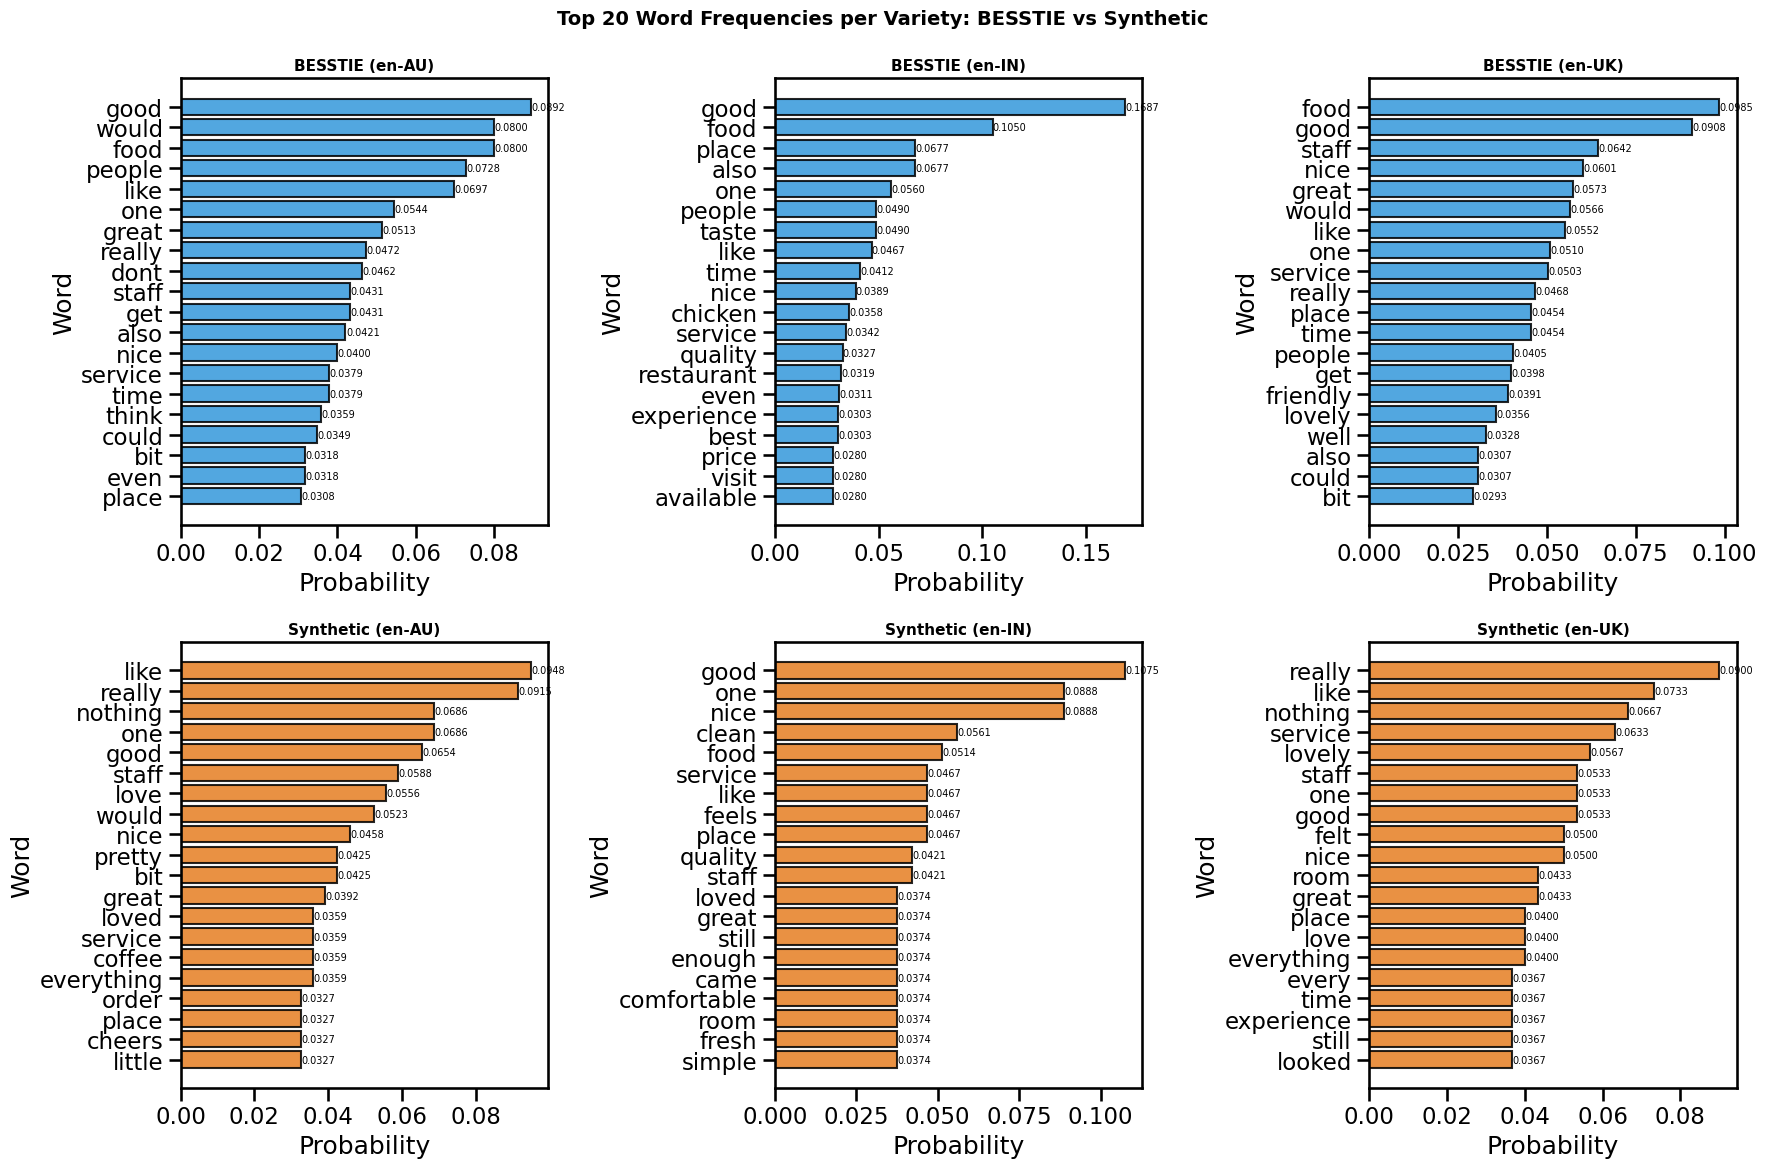

In [12]:
def get_word_freq(df, variety, top_n=20, remove_stopwords=True):
    stop_words = set(stopwords.words('english')) if remove_stopwords else set()

    texts = df[df['variety'] == variety]['text'].dropna().tolist()
    words = []
    for text in texts:
        cleaned = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        tokens = [w for w in cleaned.split()
                  if w not in stop_words and len(w) > 2]
        words.extend(tokens)

    freq = Counter(words)
    top_words = freq.most_common(top_n)

    if not top_words:
        return [], []

    return zip(*top_words)

figure, axes = plt.subplots(2, 3, figsize=(18, 12))
figure.suptitle('Top 20 Word Frequencies per Variety: BESSTIE vs Synthetic', fontsize=14, fontweight='bold')

bar_colors = {'BESSTIE': '#3498db', 'Synthetic': '#e67e22'}

for col, variety in enumerate(varieties):
    for row, (dataset_name, df) in enumerate([('BESSTIE', matched_frames), ('Synthetic', synthetic_data_frames)]):
        ax = axes[row][col]
        words, counts = get_word_freq(df, variety, top_n=20)
        words, counts = list(words), list(counts)

        total = sum(counts)
        probs = [c/total for c in counts] if total > 0 else []

        bars = ax.barh(words[::-1], probs[::-1], color=bar_colors[dataset_name], alpha=0.85, edgecolor='black')
        ax.set_title(f'{dataset_name} ({variety})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Probability')
        ax.set_ylabel('Word')
        
        # Add value labels
        for bar, prob in zip(bars, probs[::-1]):
            ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                    f'{prob:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_top_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 13 - Lexical Markers of Sarcasm

This section compares the top words used in sarcastic and non-sarcastic texts for BESSTIE and the synthetic dataset.

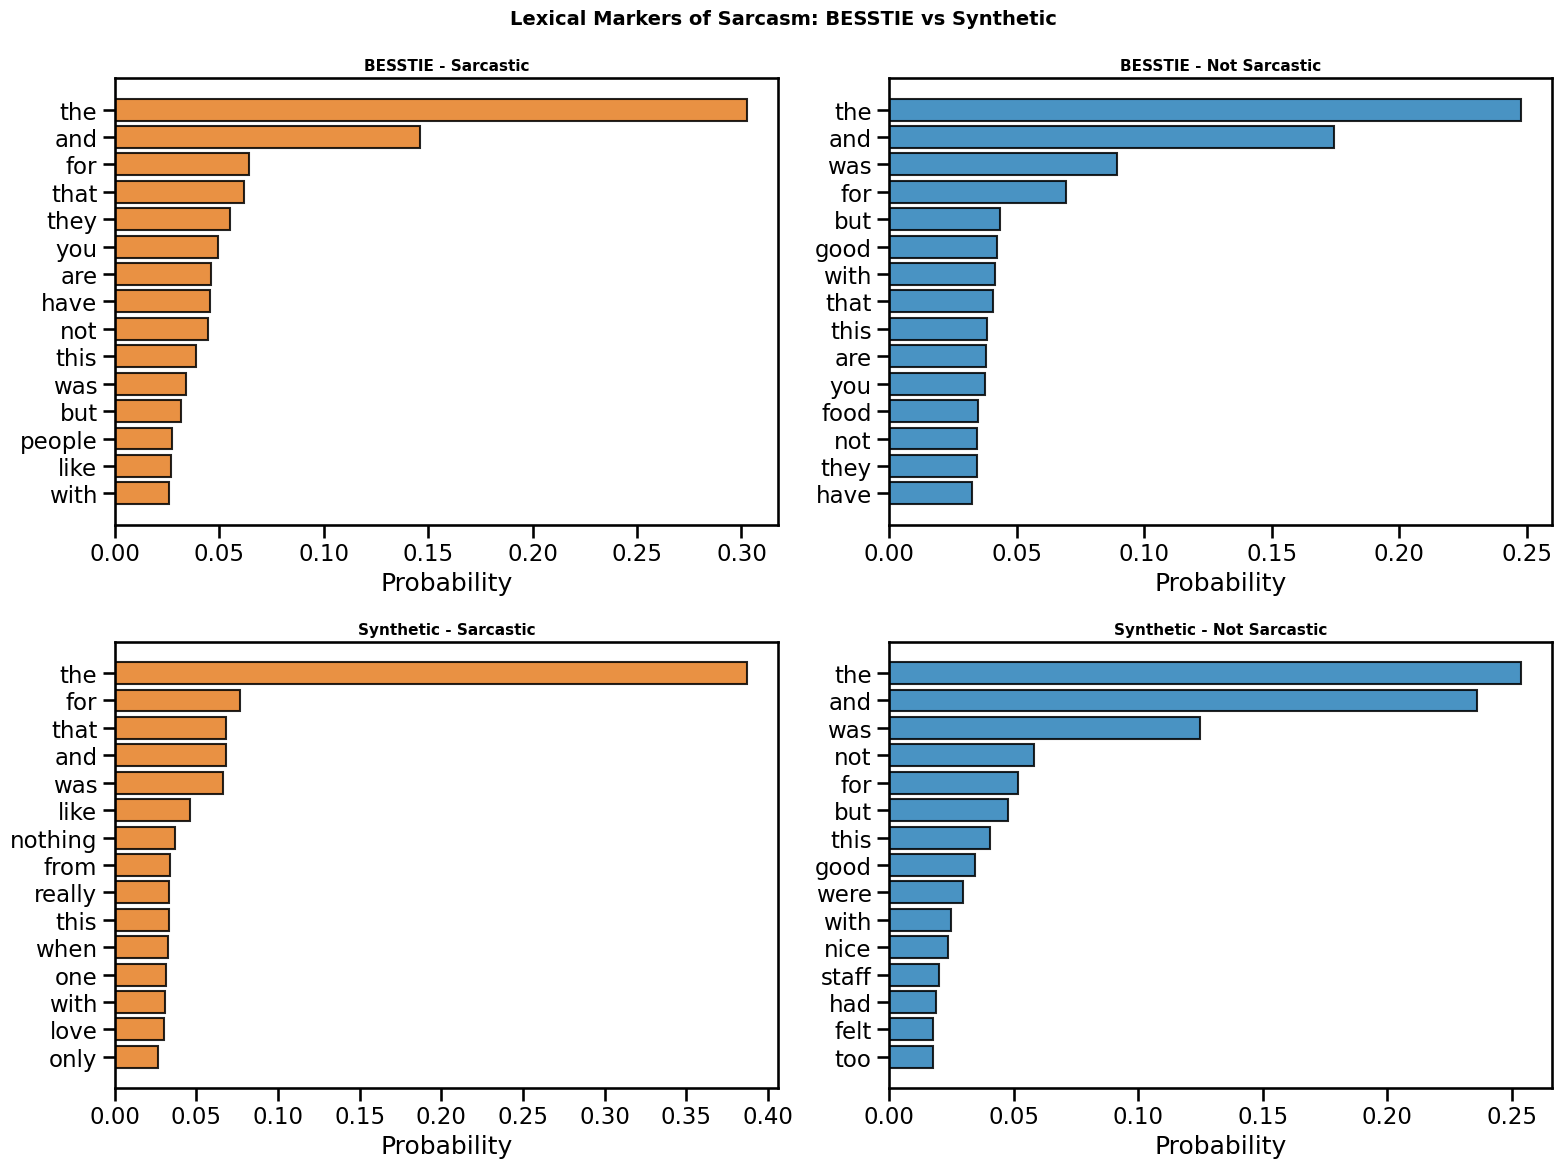

In [13]:
figure, axes = plt.subplots(2, 2, figsize=(16, 12))
figure.suptitle('Lexical Markers of Sarcasm: BESSTIE vs Synthetic', fontsize=14, fontweight='bold')

sarcasm_colors = {1.0: '#e67e22', 0.0: '#2980b9'}
sarcasm_labels = {1.0: 'Sarcastic', 0.0: 'Not Sarcastic'}

for row, (dataset_name, df) in enumerate([('BESSTIE', matched_frames), ('Synthetic', synthetic_data_frames)]):
    for col, label in enumerate([1.0, 0.0]):
        ax = axes[row][col]
        subset = df[df['Sarcasm'] == label]

        texts = subset['text'].dropna().tolist()
        words = []
        for text in texts:
            cleaned = re.sub(r'[^a-zA-Z\s]', '', text.lower())
            tokens = [w for w in cleaned.split() if len(w) > 2]
            words.extend(tokens)

        freq = Counter(words).most_common(15)
        if len(freq) == 0:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
            continue

        words, counts = zip(*freq)
        probs = [c/sum(counts) for c in counts]

        ax.barh(list(words)[::-1], probs[::-1], color=sarcasm_colors[label], alpha=0.85, edgecolor='black')
        ax.set_title(f'{dataset_name} - {sarcasm_labels[label]}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Probability')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_sarcasm_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 14 - Vocabulary Overlap Using Jaccard Similarity

This section computes Jaccard similarity among varieties within each dataset and also reports the overall vocabulary overlap between BESSTIE and the synthetic corpus.

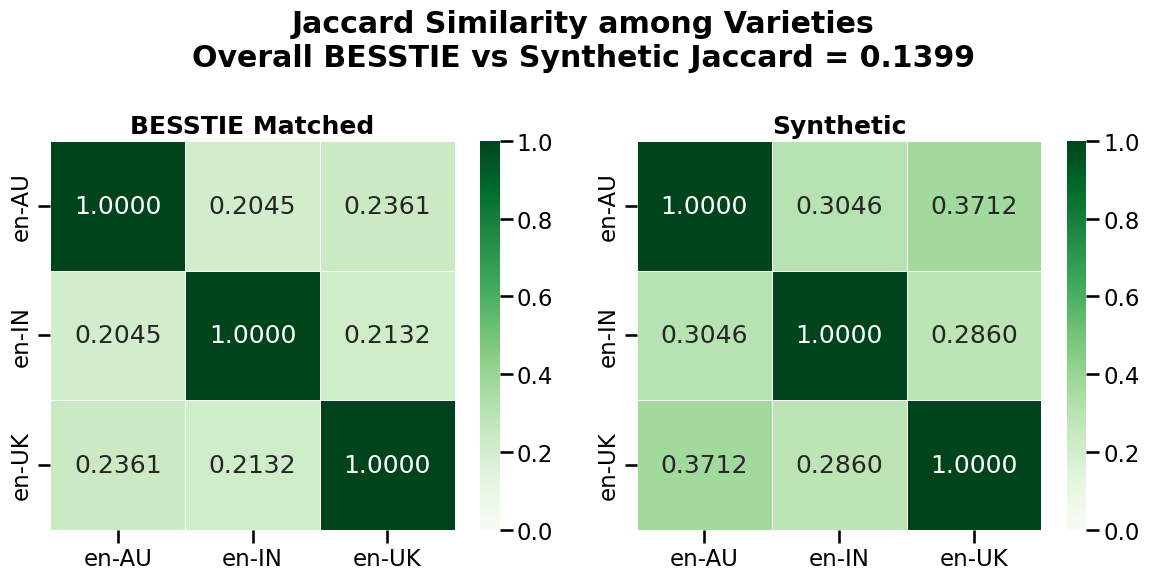


=== Vocabulary Breakdown ===
Shared tokens:          1668
Only in BESSTIE:        9429
Only in Synthetic:      830

Sample tokens only in BESSTIE:   ['camp,', 'crabs', 'fried.', 'rank', 'rental', 'tell,', 'unhurried.', 'dip', 'enjoyable.', 'available!!', 'marrriages*', 'deceitfully', 'yeah?', 'flies', 'ufo', 'food-the', 'historical', 'again!', 'door.', 'sharing']
Sample tokens only in Synthetic: ['acoustics', 'hurts', 'possums', 'slamming', 'artistry', 'stare', 'balancing', 'matched', 'setup', 'fifth', 'faq', 'auto', 'bugs', 'song', 'screaming', 'socks', 'indoors', 'neatly', 'recruiter', 'greeting']


In [14]:
def get_vocabulary(df, variety):
    texts = df[df['variety'] == variety]['text'].dropna().tolist()
    tokens = set()
    for text in texts:
        tokens.update(text.lower().split())
    return tokens

# BESSTIE matched vocabularies
vocabulary_au = get_vocabulary(matched_frames, 'en-AU')
vocabulary_uk = get_vocabulary(matched_frames, 'en-UK')
vocabulary_in = get_vocabulary(matched_frames, 'en-IN')

def jaccard(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return round(intersection / union, 4)

jaccard_matrix = pd.DataFrame(index=varieties, columns=varieties, dtype=float)
vocab_map = {'en-AU': vocabulary_au, 'en-UK': vocabulary_uk, 'en-IN': vocabulary_in}

for v1 in varieties:
    for v2 in varieties:
        intersection = len(vocab_map[v1] & vocab_map[v2])
        union = len(vocab_map[v1] | vocab_map[v2])
        jaccard_matrix.loc[v1, v2] = round(intersection / union, 4)

# Synthetic vocabularies
synthetic_vocabulary_au = get_vocabulary(synthetic_data_frames, 'en-AU')
synthetic_vocabulary_uk = get_vocabulary(synthetic_data_frames, 'en-UK')
synthetic_vocabulary_in = get_vocabulary(synthetic_data_frames, 'en-IN')

synthetic_jaccard_matrix = pd.DataFrame(index=varieties, columns=varieties, dtype=float)
synthetic_vocab_map = {'en-AU': synthetic_vocabulary_au, 'en-UK': synthetic_vocabulary_uk, 'en-IN': synthetic_vocabulary_in}

for v1 in varieties:
    for v2 in varieties:
        intersection = len(synthetic_vocab_map[v1] & synthetic_vocab_map[v2])
        union = len(synthetic_vocab_map[v1] | synthetic_vocab_map[v2])
        synthetic_jaccard_matrix.loc[v1, v2] = round(intersection / union, 4)

besstie_vocab = set([t for row in matched_frames['text'].dropna().str.lower().str.split() for t in row])
synthetic_vocab = set([t for row in synthetic_data_frames['text'].dropna().str.lower().str.split() for t in row])
overall_jaccard = jaccard(besstie_vocab, synthetic_vocab)

figure, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt='.4f', cmap='Greens', linewidths=0.5, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('BESSTIE Matched', fontweight='bold')

sns.heatmap(synthetic_jaccard_matrix.astype(float), annot=True, fmt='.4f', cmap='Greens', linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Synthetic', fontweight='bold')

plt.suptitle(f'Jaccard Similarity among Varieties\nOverall BESSTIE vs Synthetic Jaccard = {overall_jaccard}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_jaccard_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Unique tokens per dataset
only_besstie = besstie_vocab - synthetic_vocab
only_synthetic = synthetic_vocab - besstie_vocab
shared = besstie_vocab & synthetic_vocab

print(f"\n=== Vocabulary Breakdown ===")
print(f"Shared tokens:          {len(shared)}")
print(f"Only in BESSTIE:        {len(only_besstie)}")
print(f"Only in Synthetic:      {len(only_synthetic)}")
print(f"\nSample tokens only in BESSTIE:   {list(only_besstie)[:20]}")
print(f"Sample tokens only in Synthetic: {list(only_synthetic)[:20]}")

## Section 14.1 - Code-Mixed Term Inspection in en-IN

This section inspects selected en-IN terms in order to see whether the synthetic data preserves some of the lexical flavour found in BESSTIE's Indian English variety.

In [15]:
candidate_terms = ['yaar', 'acha', 'accha', 'bhai', 'only', 'na', 'hai', 'wala', 'nahi', 'arre']

def count_candidate_terms(df, variety):
    texts = " ".join(df[df['variety'] == variety]['text'].dropna().astype(str).str.lower().tolist())
    counts = {}
    for term in candidate_terms:
        counts[term] = len(re.findall(rf'\b{re.escape(term)}\b', texts))
    return pd.DataFrame({'term': list(counts.keys()), 'count': list(counts.values())})

besstie_terms = count_candidate_terms(matched_frames, 'en-IN').rename(columns={'count': 'BESSTIE_count'})
synthetic_terms = count_candidate_terms(synthetic_data_frames, 'en-IN').rename(columns={'count': 'Synthetic_count'})

term_compare = besstie_terms.merge(synthetic_terms, on='term')
display(term_compare)

term_compare.to_csv(f'{CSV_DIR}/enin_code_mixed_terms_compare.csv', index=False)

,term,BESSTIE_count,Synthetic_count
0,yaar,1,2
1,acha,0,0
2,accha,0,0
3,bhai,5,0
4,only,57,7
5,na,6,0
6,hai,20,0
7,wala,0,0
8,nahi,5,0
9,arre,0,0


## Section 15 - Variety Similarity Using TF-IDF Cosine Similarity

This section compares TF-IDF cosine similarity among varieties within BESSTIE and the synthetic dataset, and reports overall corpus-level cosine similarity between them.

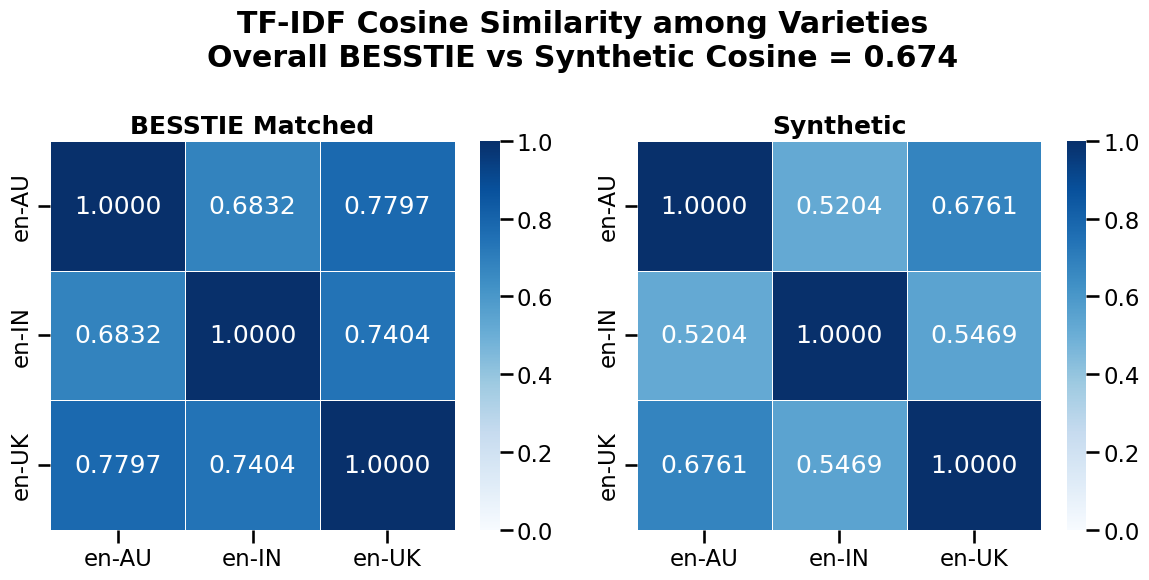

In [16]:
texts_by_variety = {v: " ".join(matched_frames[matched_frames['variety'] == v]['text'].dropna().tolist()) for v in varieties}
synthetic_texts_by_variety = {v: " ".join(synthetic_data_frames[synthetic_data_frames['variety'] == v]['text'].dropna().tolist()) for v in varieties}

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(list(texts_by_variety.values()))
cosine = cosine_similarity(tfidf_matrix)
cosine_data_frames = pd.DataFrame(cosine, index=varieties, columns=varieties)

synthetic_tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
synthetic_tfidf_matrix = synthetic_tfidf.fit_transform(list(synthetic_texts_by_variety.values()))
synthetic_cosine = cosine_similarity(synthetic_tfidf_matrix)
synthetic_cosine_data_frames = pd.DataFrame(synthetic_cosine, index=varieties, columns=varieties)

corpus = [
    " ".join(matched_frames['text'].dropna().tolist()),
    " ".join(synthetic_data_frames['text'].dropna().tolist())
]
overall_vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', max_features=5000)
overall_X = overall_vectorizer.fit_transform(corpus)
overall_cosine = cosine_similarity(overall_X)[0,1]

figure, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(cosine_data_frames, annot=True, fmt='.4f', cmap='Blues', linewidths=0.5, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('BESSTIE Matched', fontweight='bold')

sns.heatmap(synthetic_cosine_data_frames, annot=True, fmt='.4f', cmap='Blues', linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Synthetic', fontweight='bold')

plt.suptitle(f'TF-IDF Cosine Similarity among Varieties\nOverall BESSTIE vs Synthetic Cosine = {round(float(overall_cosine), 4)}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_cosine_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 15.1 - Overall Comparison Summary Table

This table provides a compact comparison between the matched BESSTIE sample and the synthetic dataset. It summarises key dataset-specific statistics, including corpus size, vocabulary size, average and median text length, and the proportions of sarcastic and positive examples. The purpose of this table is to give a high-level view of how closely the synthetic data resembles the real dataset before examining pairwise similarity measures in more detail.

In [17]:
summary_comparison = {
    'Metric': [
        'Total rows',
        'Vocabulary size',
        'Avg word length',
        'Median word length',
        'Sarcasm rate (%)',
        'Positive sentiment rate (%)',
    ],
    'BESSTIE (matched)': [
        len(matched_frames),
        len(besstie_vocab),
        round(matched_frames['word_length'].mean(), 2),
        round(matched_frames['word_length'].median(), 2),
        round(matched_frames['Sarcasm'].mean() * 100, 1),
        round(matched_frames['Sentiment'].mean() * 100, 1),
    ],
    'Synthetic': [
        len(synthetic_data_frames),
        len(synthetic_vocab),
        round(synthetic_data_frames['word_length'].mean(), 2),
        round(synthetic_data_frames['word_length'].median(), 2),
        round(synthetic_data_frames['Sarcasm'].mean() * 100, 1),
        round(synthetic_data_frames['Sentiment'].mean() * 100, 1),
    ],
}

comparison_summary_df = pd.DataFrame(summary_comparison)
print("=== BESSTIE vs Synthetic — Overall Comparison Summary ===")
display(comparison_summary_df)
comparison_summary_df.to_csv(f'{CSV_DIR}/overall_comparison_summary.csv', index=False)

similarity_summary = pd.DataFrame({
    'Metric': ['Jaccard similarity (overall)', 'Cosine similarity (overall)'],
    'Value': [overall_jaccard, round(float(overall_cosine), 4)]
})

display(similarity_summary)

=== BESSTIE vs Synthetic — Overall Comparison Summary ===


,Metric,BESSTIE (matched),Synthetic
0,Total rows,1244.00,1244.00
1,Vocabulary size,11097.00,2498.00
2,Avg word length,49.19,10.33
3,Median word length,34.00,10.00
4,Sarcasm rate (%),14.70,50.60
5,Positive sentiment rate (%),49.70,31.80


,Metric,Value
0,Jaccard similarity (overall),0.1399
1,Cosine similarity (overall),0.6740


## Section 16 - Venn Diagram of Vocabulary Overlap

This section uses Venn diagrams to visualize vocabulary overlap across varieties within BESSTIE and within the synthetic dataset.

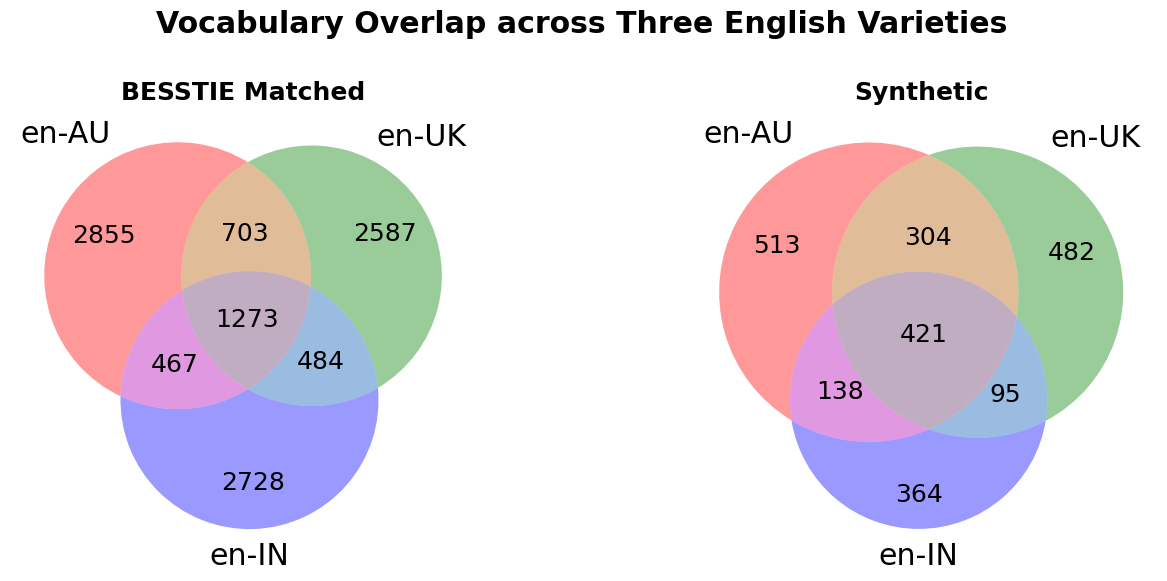

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])
venn3([vocabulary_au, vocabulary_uk, vocabulary_in], set_labels=('en-AU', 'en-UK', 'en-IN'))
axes[0].set_title('BESSTIE Matched', fontweight='bold')

plt.sca(axes[1])
venn3([synthetic_vocabulary_au, synthetic_vocabulary_uk, synthetic_vocabulary_in], set_labels=('en-AU', 'en-UK', 'en-IN'))
axes[1].set_title('Synthetic', fontweight='bold')

plt.suptitle('Vocabulary Overlap across Three English Varieties', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_venn_vocabulary.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 17 - POS Distribution Across Varieties

This section compares part-of-speech distributions across varieties for BESSTIE and the synthetic dataset in order to identify broader structural similarities or differences.

Computing POS distributions



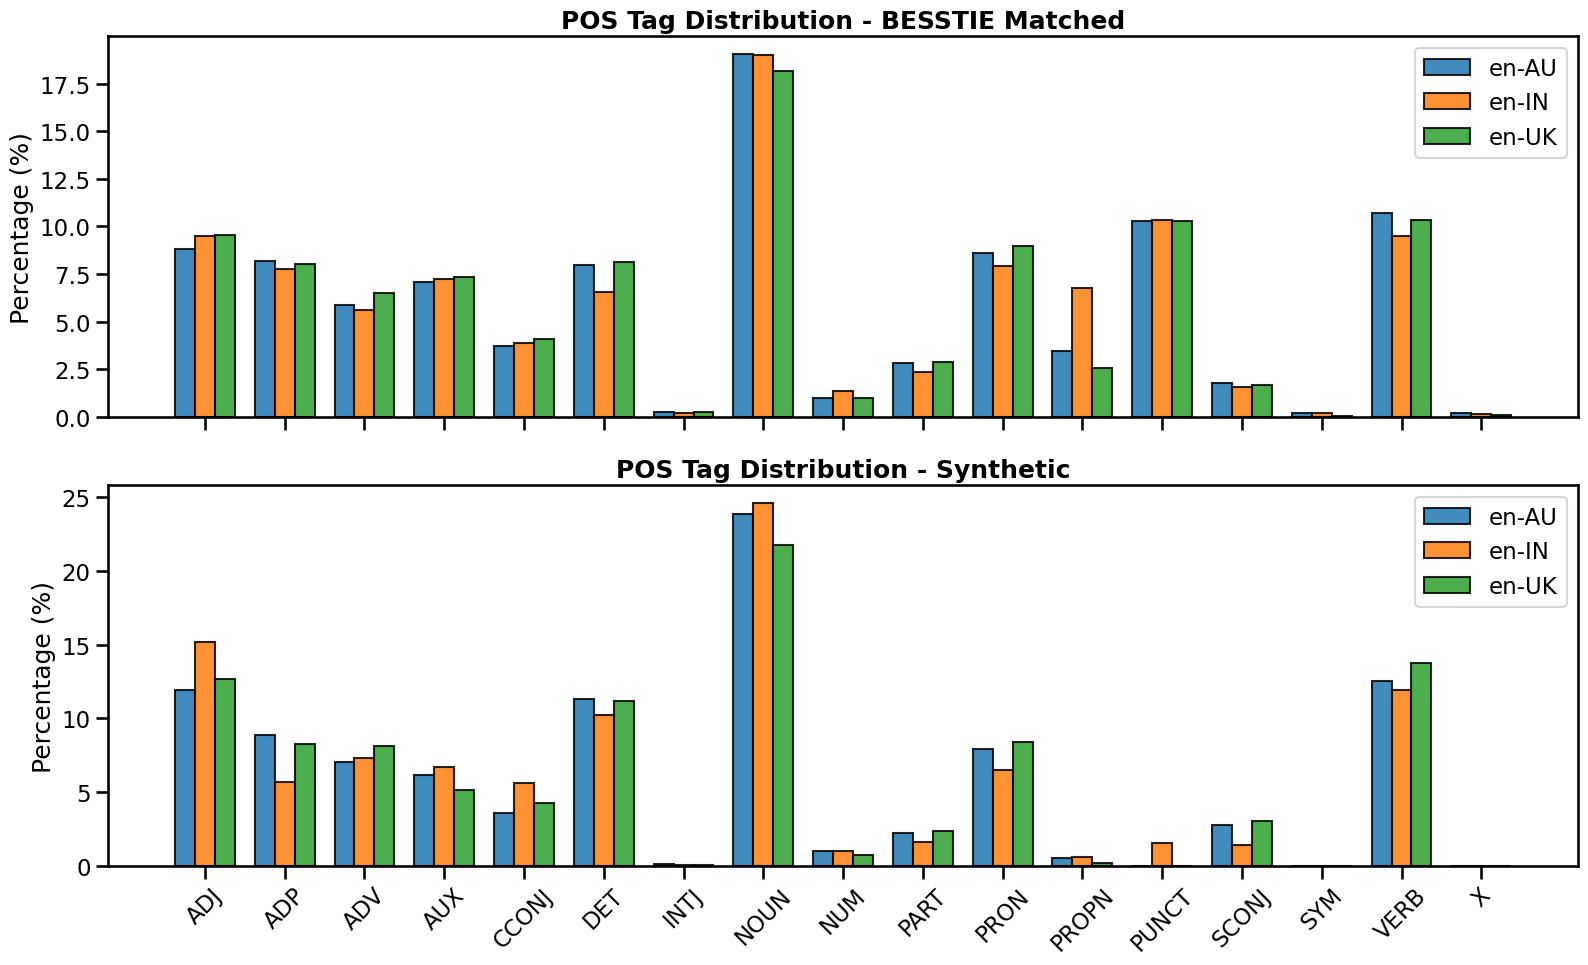

In [19]:
def get_pos_distribution(data_frames, variety, sample_size=300):
    texts = data_frames[data_frames['variety'] == variety]['text'].dropna().sample(
        min(sample_size, len(data_frames[data_frames['variety'] == variety])), random_state=42
    ).tolist()
    pos_counts = Counter()
    for text in texts:
        doc = nlp(text[:500])
        for token in doc:
            if not token.is_space:
                pos_counts[token.pos_] += 1
    total = sum(pos_counts.values())
    return {k: v/total*100 for k, v in pos_counts.items()}

print("Computing POS distributions\n")
pos_distribution = {v: get_pos_distribution(matched_frames, v) for v in varieties}
synthetic_pos_distribution = {v: get_pos_distribution(synthetic_data_frames, v) for v in varieties}

all_pos_tags = sorted(set(tag for d in pos_distribution.values() for tag in d.keys()) |
                      set(tag for d in synthetic_pos_distribution.values() for tag in d.keys()))

figure, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

x = np.arange(len(all_pos_tags))
width = 0.25

for i, variety in enumerate(varieties):
    values = [pos_distribution[variety].get(tag, 0) for tag in all_pos_tags]
    axes[0].bar(x + i*width, values, width, label=variety, alpha=0.85, edgecolor='black')
axes[0].set_title('POS Tag Distribution - BESSTIE Matched', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend()

for i, variety in enumerate(varieties):
    values = [synthetic_pos_distribution[variety].get(tag, 0) for tag in all_pos_tags]
    axes[1].bar(x + i*width, values, width, label=variety, alpha=0.85, edgecolor='black')
axes[1].set_title('POS Tag Distribution - Synthetic', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(all_pos_tags, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/synthetic_pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()